In [8]:
# Multi-Omics Disease Resistance in Common Bean (Phaseolus vulgaris)

#This project simulates genomic and transcriptomic data to predict disease resistance using machine learning models.

In [9]:
# 1. import
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

np.random.seed(42)

In [10]:
# 2. Generate Genotype
n_samples = 500
n_snps = 1000

geno = np.random.randint(0, 3, size=(n_samples, n_snps))
geno = pd.DataFrame(geno, columns=[f"SNP_{i}" for i in range(n_snps)])

# =========================
# 3. Generate Expression
# =========================
n_genes = 200

n_genes = 200

expression = []

for i in range(n_genes):
    snp = geno.iloc[:, np.random.randint(0, n_snps)]
    noise = np.random.normal(0, 0.5, n_samples)
    expr = 0.6 * snp + noise
    expression.append(expr)

expression = pd.DataFrame(expression).T
expression.columns = [f"Gene_{i}" for i in range(n_genes)]


In [11]:

# 3. generate Phenotype
# ------------------------
n_genes = 200

expression = []

for i in range(n_genes):
    snp = geno.iloc[:, np.random.randint(0, n_snps)]
    noise = np.random.normal(0, 0.5, n_samples)
    expr = 0.6 * snp + noise
    expression.append(expr)

expression = pd.DataFrame(expression).T
expression.columns = [f"Gene_{i}" for i in range(n_genes)]

In [12]:
# 4. Generate Phenotype
important_genes = expression.iloc[:, :50]

signal = important_genes.sum(axis=1)
noise = np.random.normal(0, 0.2, len(signal))

trait = pd.DataFrame({
    "Disease_Resistance": signal + noise
})

y = trait["Disease_Resistance"]

In [13]:
# 5. Define Features
X_snp = geno
X_expr = expression
X_multi = pd.concat([geno, expression], axis=1)

In [14]:
# 6. Ridge Model

def run_model(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)

    print(f"{name} R²: {r2:.3f}")

print("\n--- Ridge Results ---")
run_model(X_snp, y, "SNP only")
run_model(X_expr, y, "Expression only")
run_model(X_multi, y, "Multi-omics")


--- Ridge Results ---
SNP only R²: 0.184
Expression only R²: 0.998
Multi-omics R²: 0.593


In [15]:
# 7. XGBoost Model
def run_xgb(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = XGBRegressor(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)

    print(f"{name} (XGB) R²: {r2:.3f}")

print("\n--- XGBoost Results ---")
run_xgb(X_expr, y, "Expression only")
run_xgb(X_multi, y, "Multi-omics")


--- XGBoost Results ---
Expression only (XGB) R²: 0.370
Multi-omics (XGB) R²: 0.294


In [16]:
# 8. Feature Importance
model = XGBRegressor(n_estimators=100)
model.fit(X_multi, y)

importance_df = pd.DataFrame({
    "Feature": X_multi.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(importance_df.head(10))


Top Features:
      Feature  Importance
207   SNP_207    0.046019
532   SNP_532    0.025731
610   SNP_610    0.024105
93     SNP_93    0.023950
356   SNP_356    0.023100
715   SNP_715    0.019841
571   SNP_571    0.019678
1029  Gene_29    0.017005
723   SNP_723    0.016094
431   SNP_431    0.015654


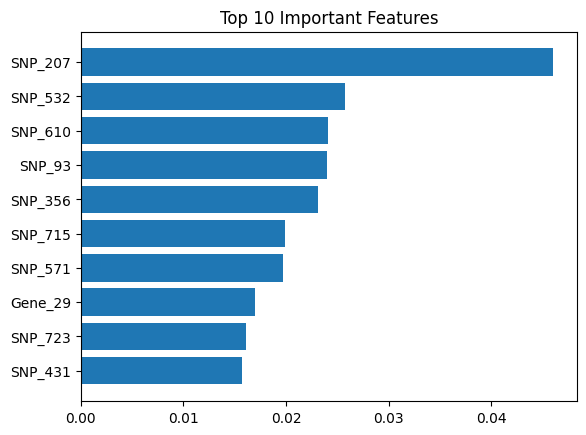

In [17]:
# 9. Plot
top = importance_df.head(10)

plt.figure()
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [18]:
from sklearn.model_selection import cross_val_score

def run_cv(X, y, name):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    scores = cross_val_score(model, X, y, cv=5, scoring="r2")

    print(f"{name} CV R²: {scores.mean():.3f} ± {scores.std():.3f}")

In [19]:
run_cv(X_expr, y, "Expression only")
run_cv(X_multi, y, "Multi-omics")

Expression only CV R²: 0.997 ± 0.001
Multi-omics CV R²: 0.453 ± 0.045


In [20]:
!pip install shap

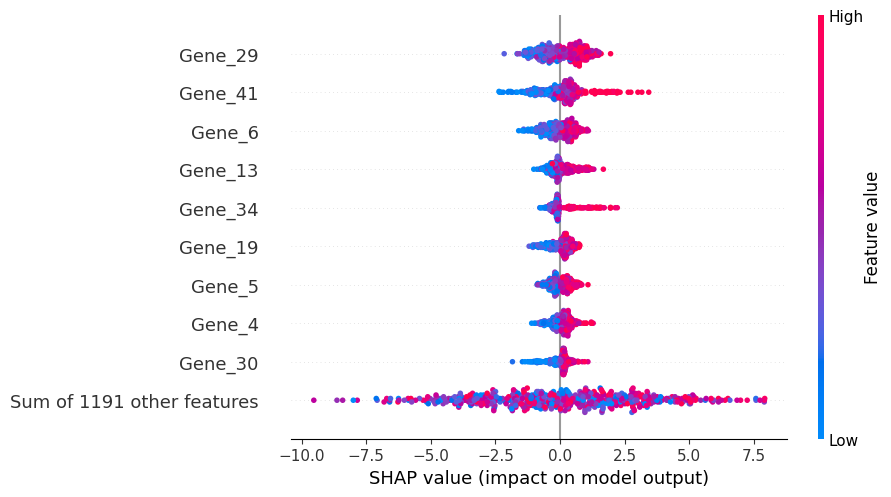

In [21]:
import shap

# train model
model = XGBRegressor(n_estimators=100)
model.fit(X_multi, y)

#  produce explainer
explainer = shap.Explainer(model, X_multi)

# calculate shap values
shap_values = explainer(X_multi)

# plot
shap.plots.beeswarm(shap_values)

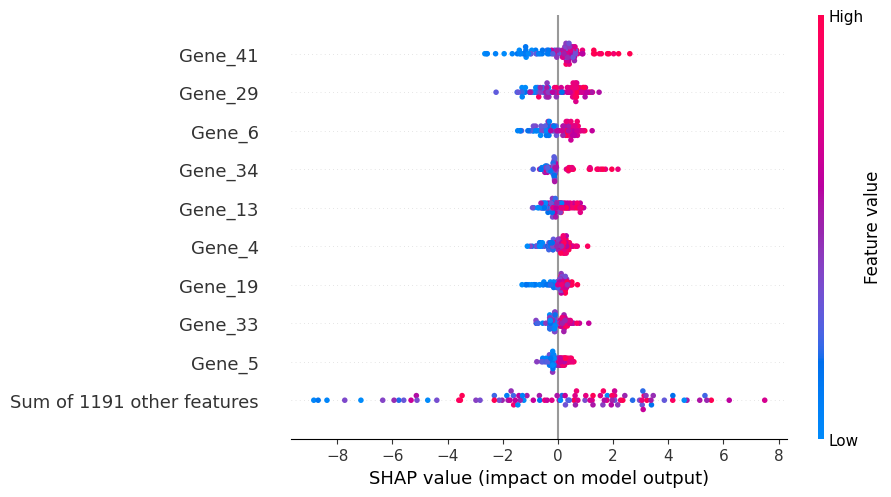

In [22]:
X_sample = X_multi.sample(100, random_state=42)
explainer = shap.Explainer(model, X_sample)
shap_values = explainer(X_sample)
shap.plots.beeswarm(shap_values)